In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid',palette='viridis', context='notebook')

In [4]:

df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.shape

(32581, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [8]:
df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


<Axes: xlabel='loan_status', ylabel='count'>

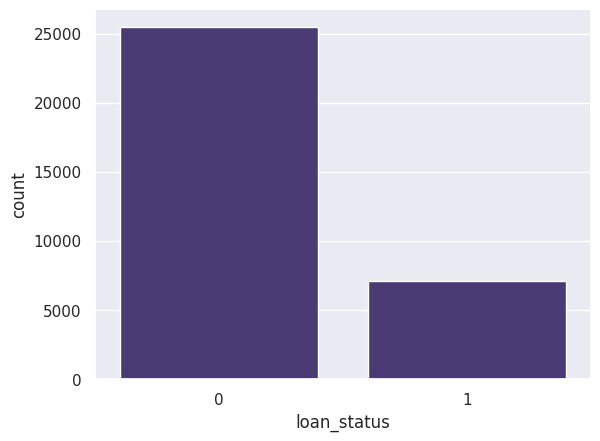

In [9]:
sns.countplot(x='loan_status', data=df)

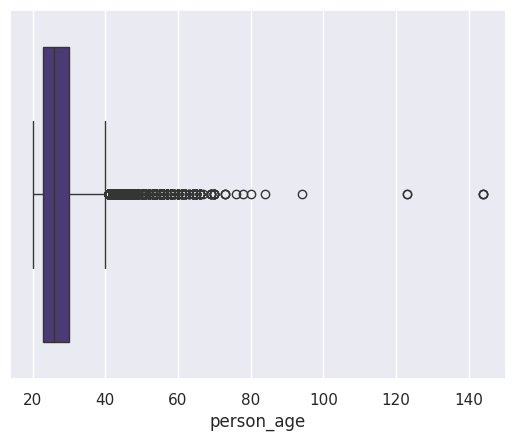

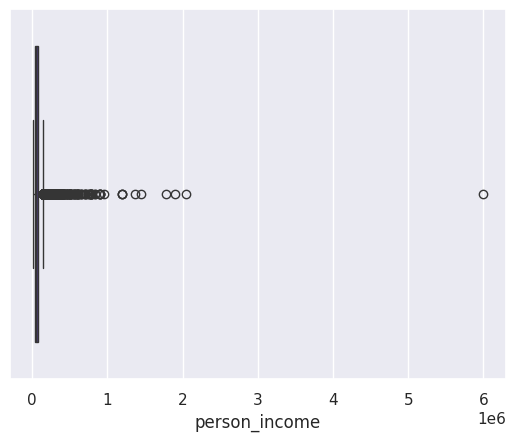

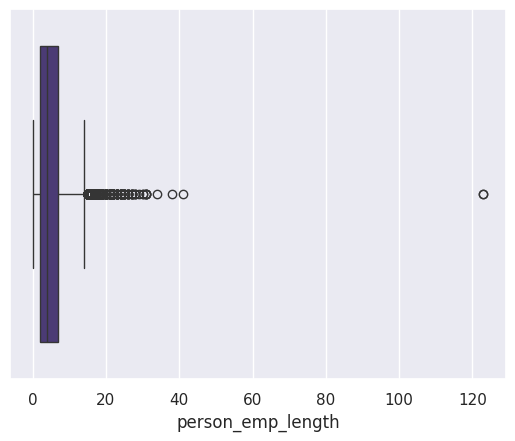

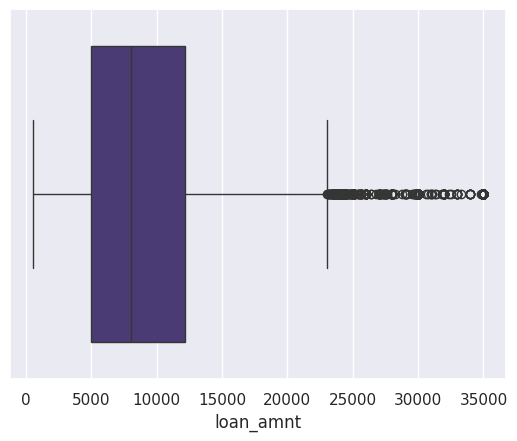

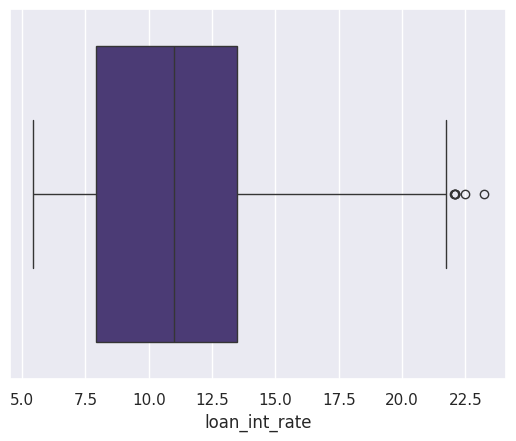

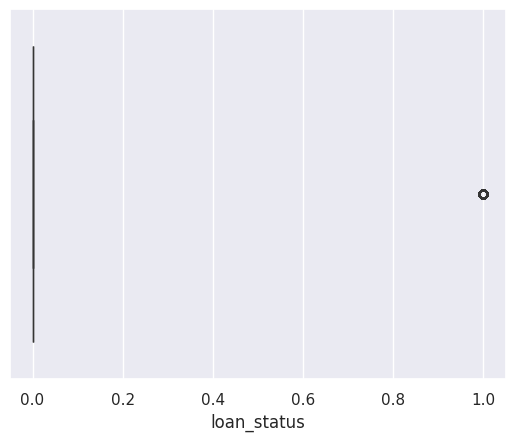

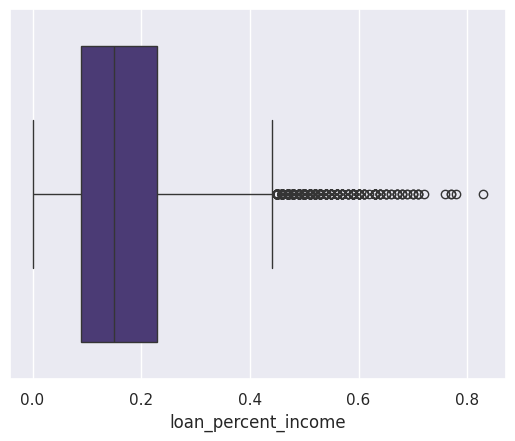

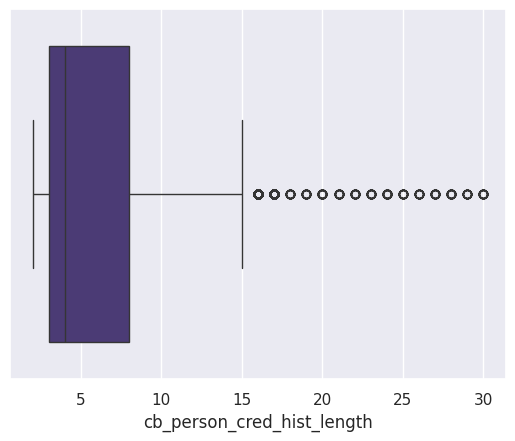

In [10]:
numerical_cols = df.select_dtypes(include=[float, int]).columns

for i in numerical_cols:
  sns.boxplot(x=df[i])
  plt.show()


In [11]:
(df['person_age'] > 100).sum()

np.int64(5)

In [12]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

In [13]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


<Axes: >

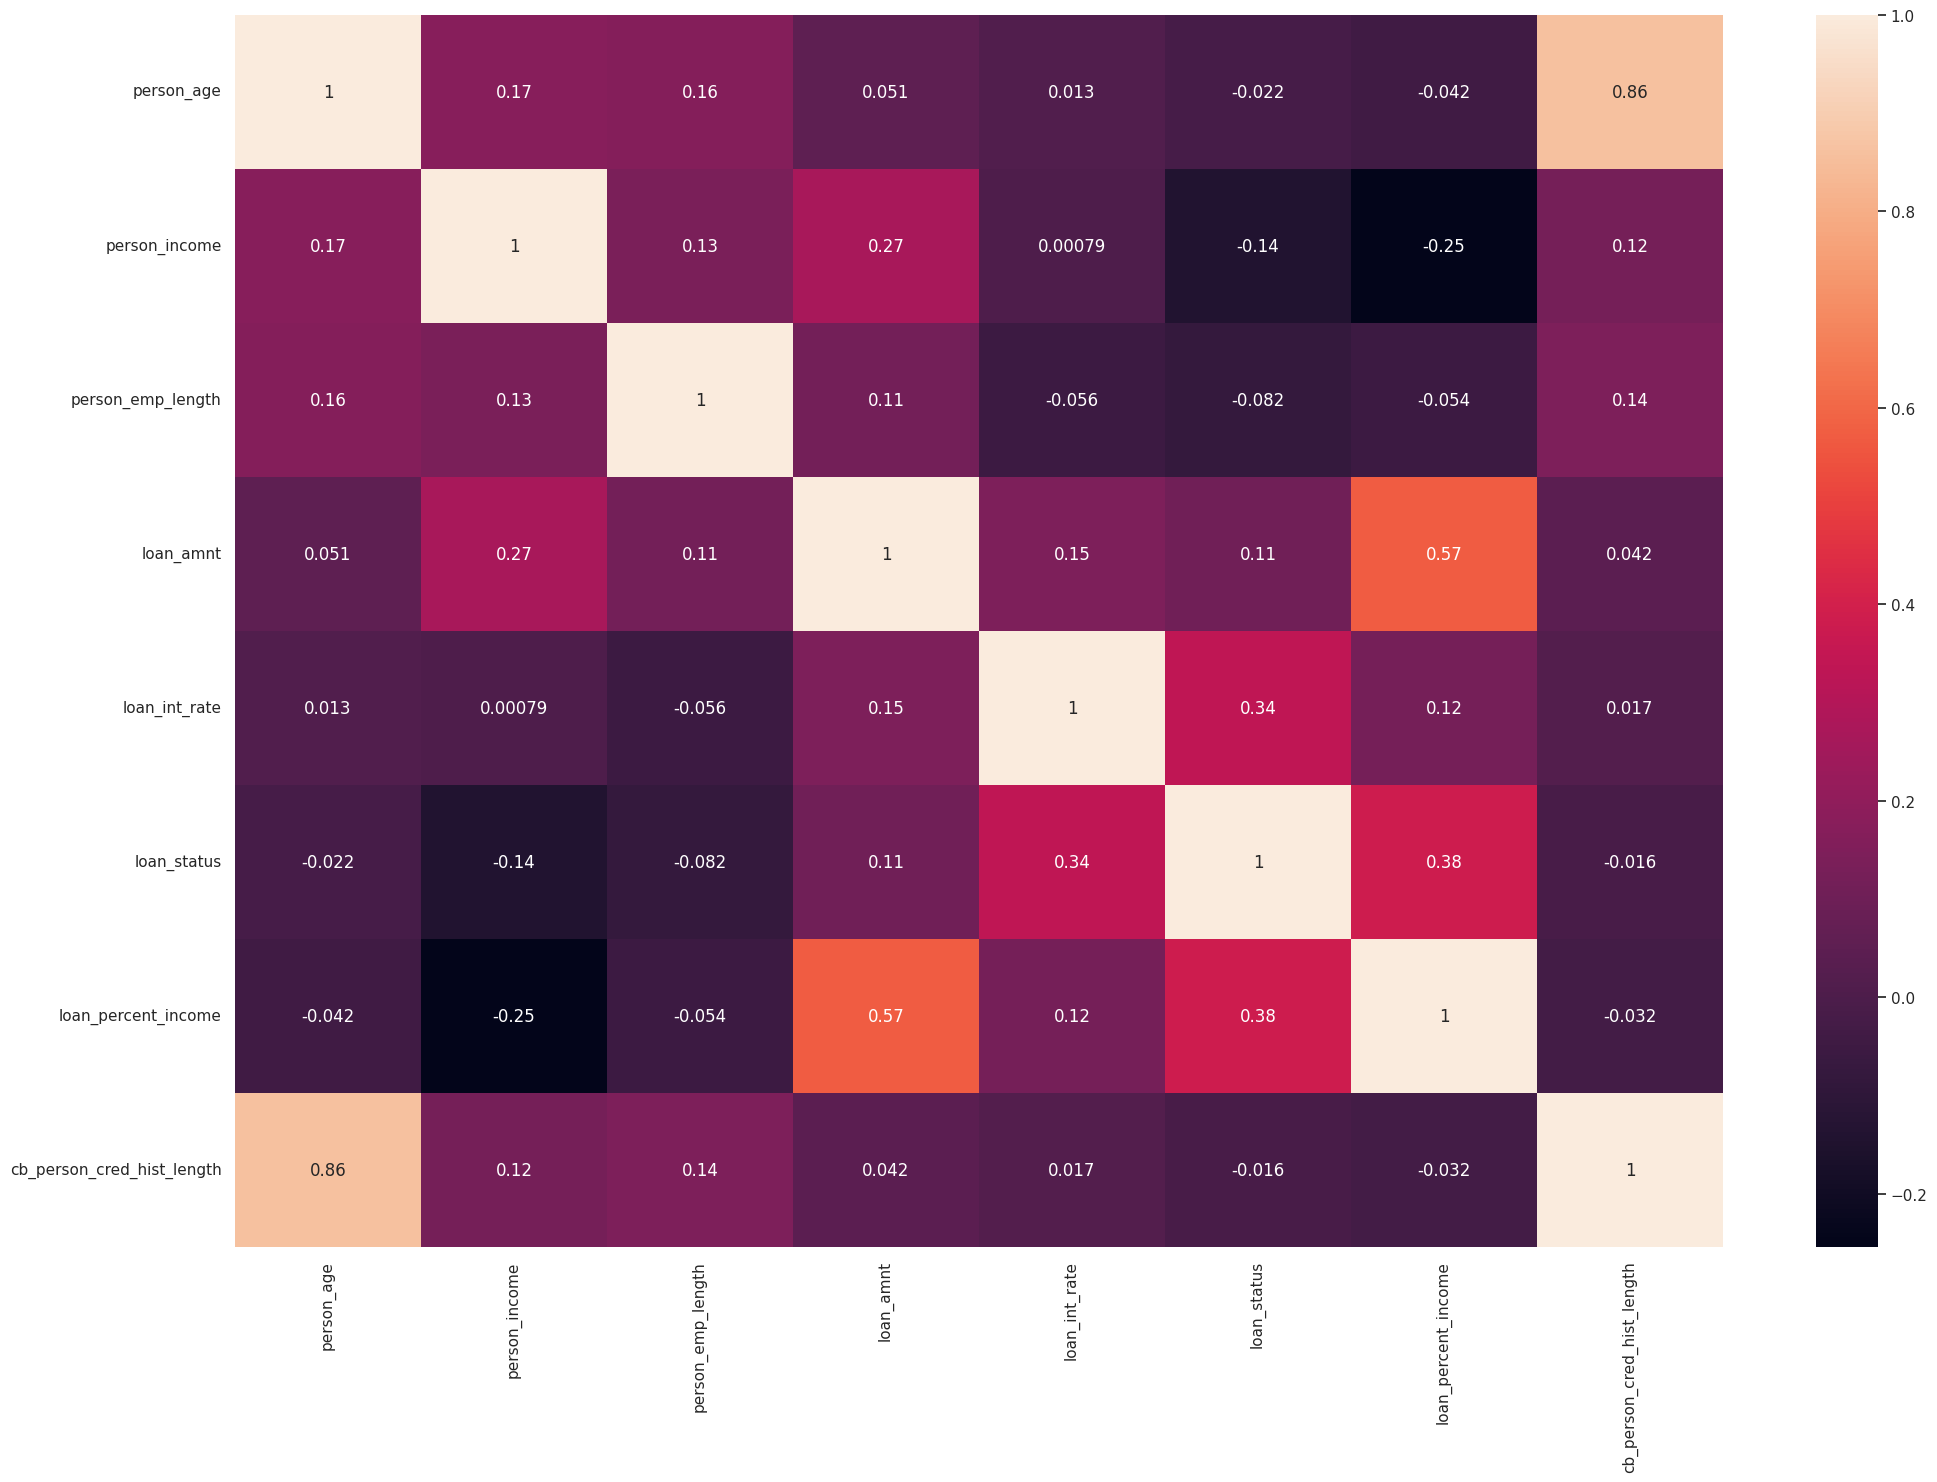

In [14]:
plt.figure(figsize=(24,16))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [15]:
df_copy = df.copy()

df_copy.drop_duplicates(inplace=True)

df_copy.shape[0]

32416

In [16]:
# removing extreme outliers in age

df_copy = df_copy[df_copy['person_age'] >=18]
df_copy = df_copy[df_copy['person_age'] <=100]

In [17]:
# Removing extreme outliers in emp length

df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

In [18]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
numeric_cols = X.select_dtypes(include=[float, int]).columns
categorical_cols = X.select_dtypes(include='object').columns

# To handle class imbalancement

In [21]:
neg, pos = np.bincount(y_train)
scale_weights = neg/pos

scale_weights

np.float64(3.6312213039485766)

# Preprocessing for logistic regression

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        #Pipeline  for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),

        #Pipeline  for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])


# preprocessig for XGBoost

In [23]:
#XGBoost: Impute numeric only (No Scaling), impute + One - Hot Encoding

preprocessor_xg = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols),

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])



# **Cross Validation on Both of them**

In [24]:
from sklearn.linear_model import LogisticRegression
lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ("classifier", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42))
])

In [25]:
from xgboost import XGBClassifier
xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimator=700, max_depth=8, learning_rate=0.1,
        scale_pos_weight=scale_weights,random_state=42
    ))
])

In [26]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [27]:
for cv_name, pipe in [("Logistic Regression", lr_cv_pipeline),
                      ("XGBoost", xgb_cv_pipeline)]:

                      cv_results = cross_validate(pipe, X_train , y_train, cv=cv, scoring=scoring, n_jobs=-1)

                      print(cv_name)
                      print("-------------------")
                      print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
                      print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
                      print(f"Precision : {cv_results['test_precision'].mean()}")
                      print(f"Recall : {cv_results['test_recall'].mean()}")
                      print(f"F1 : {cv_results['test_f1'].mean()}")
                      print()


Logistic Regression
-------------------
ROC-AUC : 0.8705112830525306
Accuracy : 0.8115949542892269
Precision : 0.5448226008889892
Recall : 0.7781450872359963
F1 : 0.6408013995933108

XGBoost
-------------------
ROC-AUC : 0.9441045074278342
Accuracy : 0.9240591264058517
Precision : 0.8557889618866834
Recall : 0.7799816345270891
F1 : 0.8159805477560381



# Selecting XGBoost for hyperparam tuning

In [28]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        scale_pos_weight=scale_weights,random_state=42))
])
xg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Mis...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve

def evaluate_model(model_name, model, X_test, y_test, threshold=None):

  y_pred_prob = model.predict_proba(X_test)[:,1]

  if threshold is not None:
      y_pred = (y_pred_prob >= threshold).astype(int)
  else:
      y_pred = model.predict(X_test)


  accuracy     = accuracy_score(y_test, y_pred)
  precision    = precision_score(y_test, y_pred)
  recall       = recall_score(y_test, y_pred)
  f1           = f1_score(y_test, y_pred)

  conf_matrix   = confusion_matrix(y_test, y_pred)
  class_report  = classification_report(y_test, y_pred)


  print(f"{model_name} Metrics:")

  if threshold is not None:
    print(f"Used Threshold : {threshold:.2f}")

  print(f"Accuracy : {accuracy:.2f}")
  print(f"Precision : {precision:.2f}")
  print(f"Recall : {recall:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)



  sns.heatmap(conf_matrix, annot=True, fmt="d")
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()



  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()

XGBoost Metrics:
Accuracy : 0.92
Precision : 0.83
Recall : 0.81
F1 : 0.82

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4943
           1       0.83      0.81      0.82      1362

    accuracy                           0.92      6305
   macro avg       0.89      0.88      0.89      6305
weighted avg       0.92      0.92      0.92      6305



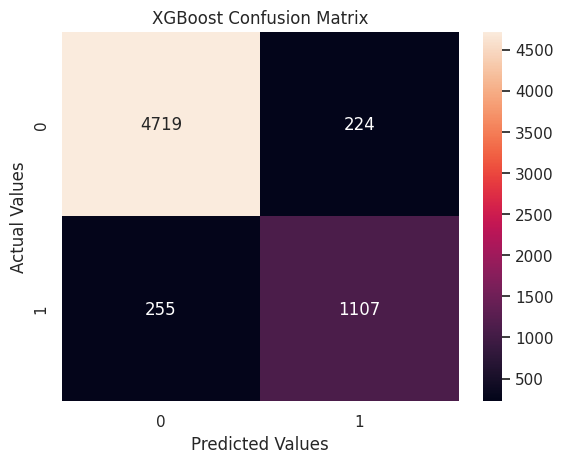

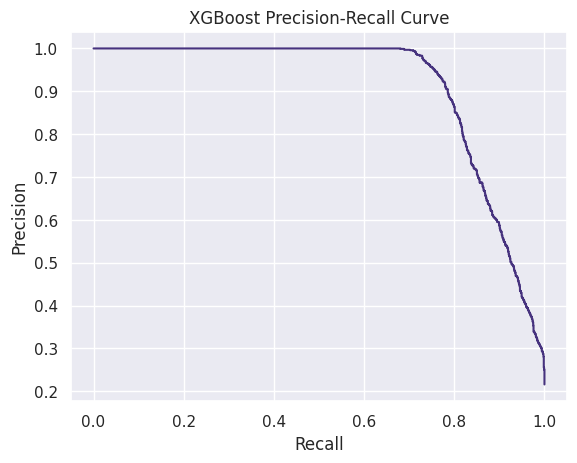

In [30]:
evaluate_model("XGBoost", xg_model, X_test, y_test)

**Hyperparam tuning by randomizedsearch**

In [31]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_grid = {
    "classifier__n_estimators": randint(150, 900),
    "classifier__max_depth" : randint(3,9),
    "classifier__learning_rate" : uniform(0.01, 0.5),
    "classifier__subsample": uniform(0.6,0.4), #Rows sampling
    "classifier__colsample_bytree" :uniform(0.6,0.4), #column sampling
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0 , 5)
}

In [32]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x789082fa9bd0>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78908338bb60>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x789082fa9810>},
                   scoring='average_precision', verbose=1)

In [33]:
print(f"Score after performing Tunning {random_search.best_score_:.2f}")

Score after performing Tunning 0.90


In [34]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.6227874682487736),
 'classifier__gamma': np.float64(1.9512413145136671),
 'classifier__learning_rate': np.float64(0.10263093785674542),
 'classifier__max_depth': 6,
 'classifier__min_child_weight': 1,
 'classifier__n_estimators': 577,
 'classifier__subsample': np.float64(0.8014804340647548)}

XGBoost Metrics:
Accuracy : 0.92
Precision : 0.84
Recall : 0.80
F1 : 0.82

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      4943
           1       0.84      0.80      0.82      1362

    accuracy                           0.92      6305
   macro avg       0.89      0.88      0.89      6305
weighted avg       0.92      0.92      0.92      6305



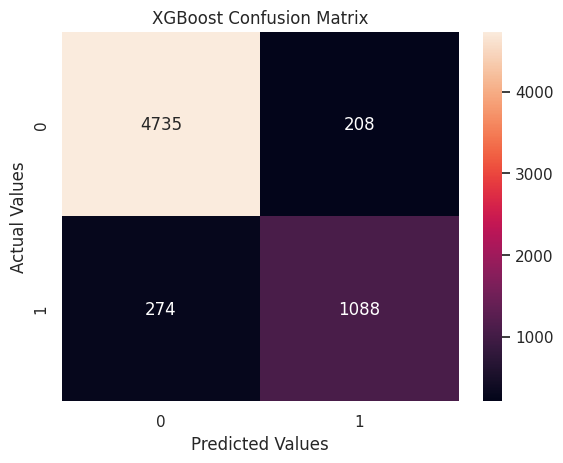

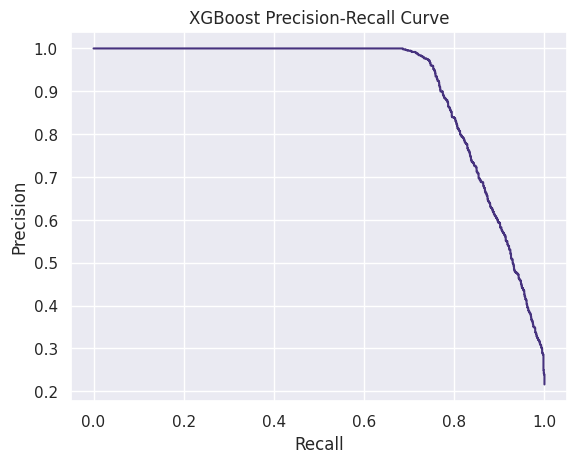

In [35]:
evaluate_model("XGBoost", random_search, X_test, y_test)

# Trying RandomForest

**Using preprocessor of xg as StandardScalar is not compulsory**

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

Random Forest Metrics:
Accuracy : 0.94
Precision : 0.98
Recall : 0.72
F1 : 0.83

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4943
           1       0.98      0.72      0.83      1362

    accuracy                           0.94      6305
   macro avg       0.95      0.86      0.90      6305
weighted avg       0.94      0.94      0.93      6305



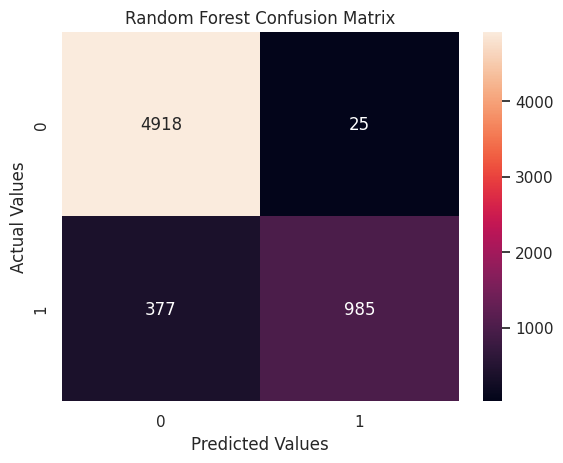

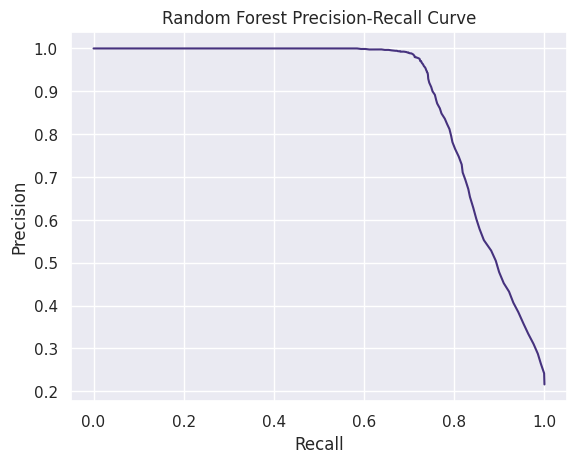

In [37]:
evaluate_model("Random Forest", rf_model, X_test, y_test)

# **Cross Validation test side by side**

In [73]:
from sklearn.model_selection import cross_val_score

cv = cross_val_score(rf_model, X_train, y_train, cv=5, scoring="average_precision", n_jobs=-1)
cv.mean()

np.float64(0.8780488641000405)

In [75]:
cv = cross_val_score(xg_model, X_train, y_train, cv=5, scoring="average_precision", n_jobs=-1)
cv.mean()

np.float64(0.90289160778257)

## **Optimizing the Classification Threshold of both**

Random Forest Metrics:
Used Threshold : 0.45
Accuracy : 0.94
Precision : 0.96
Recall : 0.73
F1 : 0.83

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4943
           1       0.96      0.73      0.83      1362

    accuracy                           0.94      6305
   macro avg       0.94      0.86      0.90      6305
weighted avg       0.94      0.94      0.93      6305



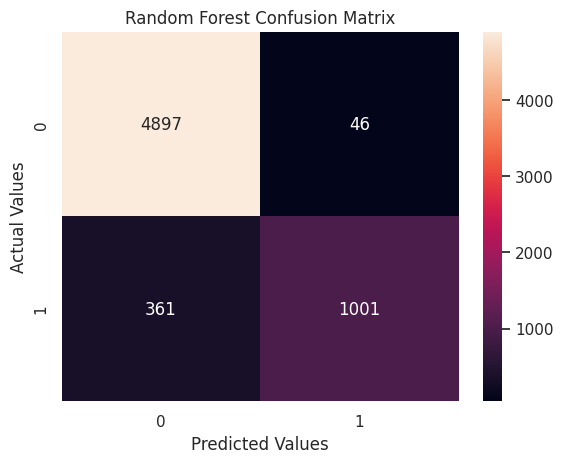

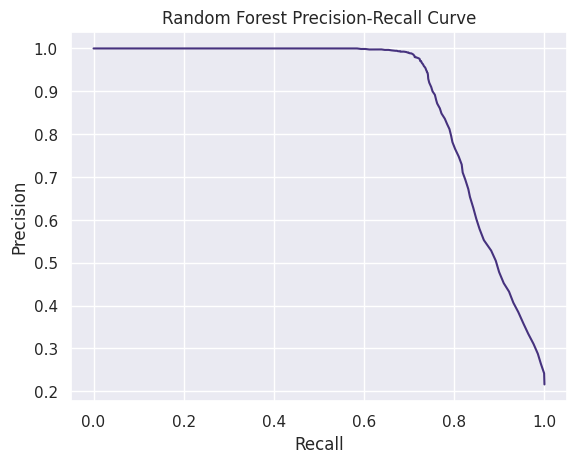

In [76]:
prob = rf_model.predict_proba(X_test)[:, 1]

#For each threshold calculate Precision and Recall
precisions, recalls , thresholds = precision_recall_curve(y_test, prob)


#Calculate F1 score for each threshold
f1 = 2 * (precisions*recalls) / (precisions + recalls + 1e-9)

#Get the threshold that produces the highest f1-score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]


evaluate_model("Random Forest", rf_model, X_test, y_test, best_threshold)

XGBoost Metrics:
Used Threshold : 0.64
Accuracy : 0.94
Precision : 0.92
Recall : 0.78
F1 : 0.84

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      4943
           1       0.92      0.78      0.84      1362

    accuracy                           0.94      6305
   macro avg       0.93      0.88      0.90      6305
weighted avg       0.94      0.94      0.94      6305



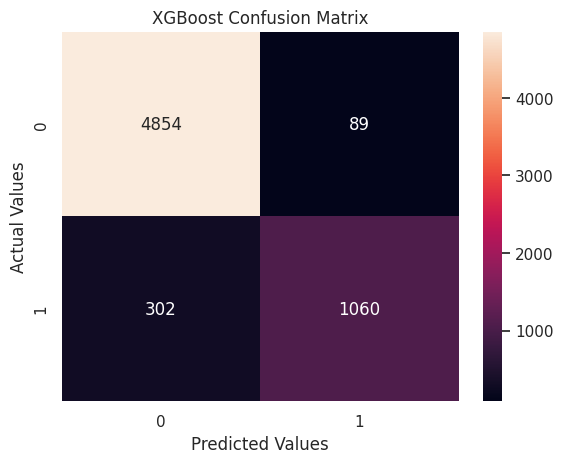

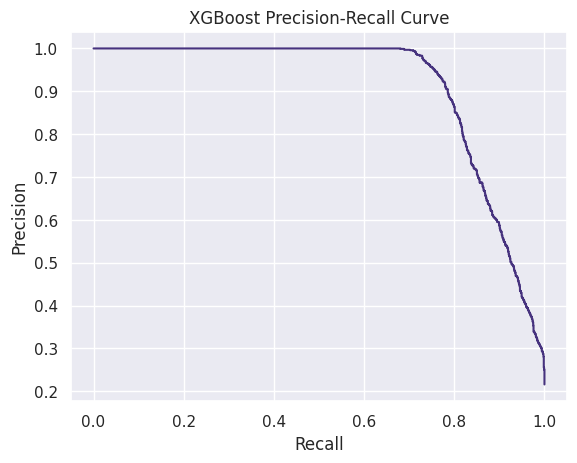

In [94]:
xg_prob = xg_model.predict_proba(X_test)[:, 1]

#For each threshold calculate Precision and Recall
xg_precisions, xg_recalls , xg_thresholds = precision_recall_curve(y_test, xg_prob)

#Get the threshold that produces the highest f1-score
xg_best = np.argmax(f1[:-1])
xg_best_threshold = xg_thresholds[xg_best]


evaluate_model("XGBoost", xg_model, X_test, y_test, xg_best_threshold)

# Probability Calibration

In [78]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

calibrated_model = CalibratedClassifierCV(
    xg_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)


CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('...
                                                                feature_weights=None,
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=None,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=None,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=None,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [83]:
uncalibrated = xg_model.predict_proba(X_test)[:,1]
calibrated = calibrated_model.predict_proba(X_test)[:,1]

In [84]:
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)

In [85]:
actual_cal, predicted_cal  = calibration_curve(y_test, calibrated, n_bins=10)

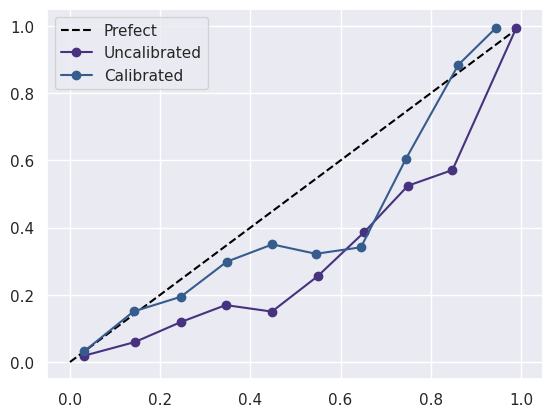

In [86]:
plt.plot([0,1], [0,1], 'k--', label="Prefect")
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "Calibrated"
)
plt.legend()


**Using this calibrated model**

# **SHAP Interpretation**

In [44]:
!pip install shap

In [87]:
import shap

xg_classifier = xg_model.named_steps['classifier']
xg_classifier

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [88]:
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)
X_test_transformed

array([[2.4000e+01, 3.0000e+04, 1.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [2.3000e+01, 6.0000e+04, 6.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [2.9000e+01, 1.8000e+04, 2.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       ...,
       [2.5000e+01, 4.8996e+04, 8.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [2.7000e+01, 1.1500e+05, 1.1000e+01, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [3.2000e+01, 5.0000e+04, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00]])

In [89]:
feature_names = xg_model.named_steps['preprocessor'].get_feature_names_out()
feature_names

array(['num__person_age', 'num__person_income', 'num__person_emp_length',
       'num__loan_amnt', 'num__loan_int_rate', 'num__loan_percent_income',
       'num__cb_person_cred_hist_length',
       'cat__person_home_ownership_MORTGAGE',
       'cat__person_home_ownership_OTHER',
       'cat__person_home_ownership_OWN',
       'cat__person_home_ownership_RENT',
       'cat__loan_intent_DEBTCONSOLIDATION', 'cat__loan_intent_EDUCATION',
       'cat__loan_intent_HOMEIMPROVEMENT', 'cat__loan_intent_MEDICAL',
       'cat__loan_intent_PERSONAL', 'cat__loan_intent_VENTURE',
       'cat__loan_grade_A', 'cat__loan_grade_B', 'cat__loan_grade_C',
       'cat__loan_grade_D', 'cat__loan_grade_E', 'cat__loan_grade_F',
       'cat__loan_grade_G', 'cat__cb_person_default_on_file_N',
       'cat__cb_person_default_on_file_Y'], dtype=object)

In [90]:
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)
X_test_df

,num__person_age,num__person_income,num__person_emp_length,num__loan_amnt,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,...,cat__loan_intent_VENTURE,cat__loan_grade_A,cat__loan_grade_B,cat__loan_grade_C,cat__loan_grade_D,cat__loan_grade_E,cat__loan_grade_F,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y
0,24.0,30000.0,1.0,15000.0,15.68,0.50,3.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,23.0,60000.0,6.0,25600.0,10.99,0.43,4.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,29.0,18000.0,2.0,3600.0,15.27,0.20,6.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,32.0,130000.0,7.0,13000.0,12.69,0.10,8.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,23.0,45288.0,7.0,20500.0,9.25,0.45,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6300,21.0,75000.0,5.0,20000.0,13.11,0.27,2.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
6301,29.0,265000.0,2.0,25000.0,11.26,0.09,10.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6302,25.0,48996.0,8.0,5000.0,9.88,0.10,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6303,27.0,115000.0,11.0,8000.0,7.51,0.07,7.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [91]:
explainer = shap.TreeExplainer(xg_classifier)
explainer

In [50]:
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[[ 0.00842856, -0.00842856],
        [ 0.01111148, -0.01111148],
        [-0.00648282,  0.00648282],
        ...,
        [ 0.00279571, -0.00279571],
        [ 0.00215809, -0.00215809],
        [ 0.00874637, -0.00874637]],

       [[ 0.00192997, -0.00192997],
        [ 0.06945103, -0.06945103],
        [ 0.02814458, -0.02814458],
        ...,
        [ 0.00115231, -0.00115231],
        [ 0.00195445, -0.00195445],
        [ 0.00473426, -0.00473426]],

       [[ 0.01275785, -0.01275785],
        [-0.30847232,  0.30847232],
        [ 0.00101373, -0.00101373],
        ...,
        [ 0.00191041, -0.00191041],
        [ 0.00677157, -0.00677157],
        [ 0.00514342, -0.00514342]],

       ...,

       [[-0.00067906,  0.00067906],
        [-0.02279876,  0.02279876],
        [-0.00886696,  0.00886696],
        ...,
        [ 0.00074907, -0.00074907],
        [ 0.01195888, -0.01195888],
        [ 0.01022987, -0.01022987]],

       [[ 0.01159826, -0.01159826],
        [ 0.10789808, -0.10

**Global explanation**

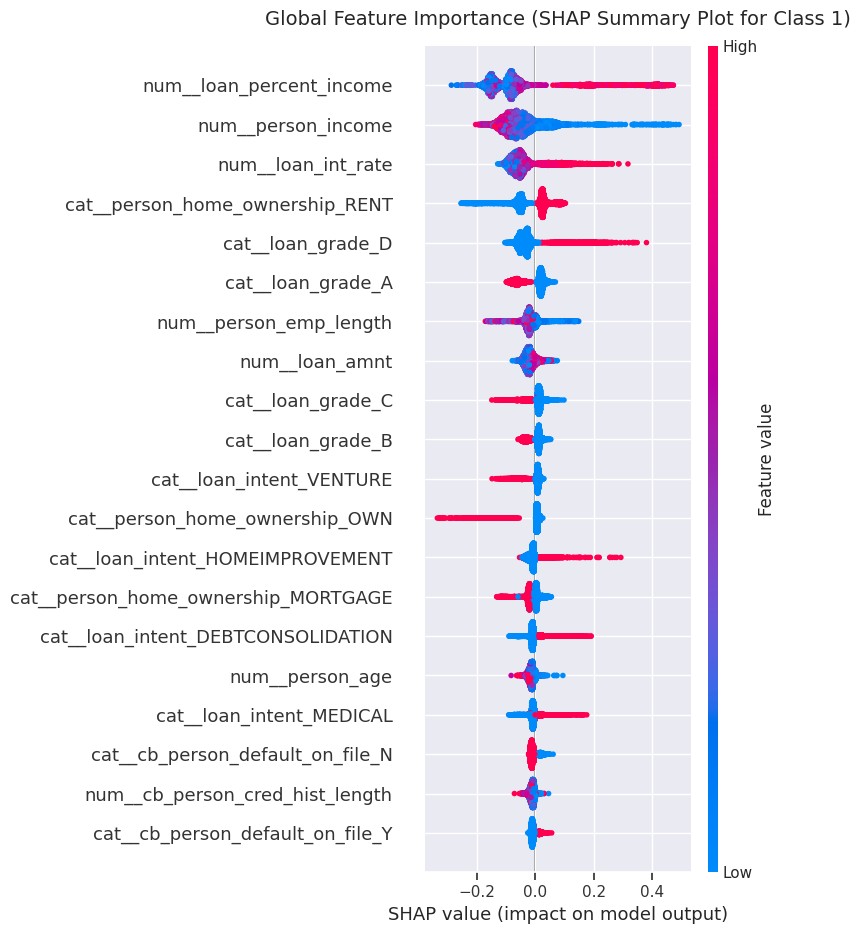

In [58]:
import matplotlib.pyplot as plt

# Set the figure size to be clean and clear
plt.figure(figsize=(10, 8))

shap.summary_plot(shap_values[:, :, 1], X_test_df, plot_type="dot", show=False)

plt.title("Global Feature Importance (SHAP Summary Plot for Class 1)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

**Local Explanation**

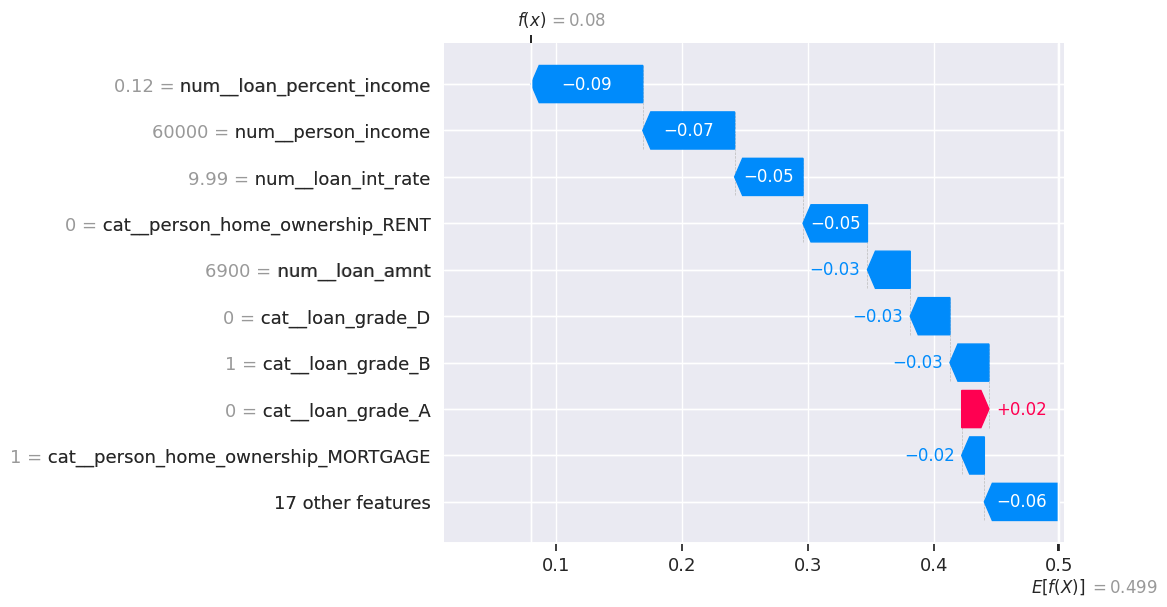

In [56]:
# 1. Pick one row to explain, e.g. the 5th applicant in the test set
row_index = 5

# 2. Draw a waterfall plot showing how each feature pushed the prediction up or down.

shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index, :, 1],
        base_values = explainer.expected_value[1],
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

# Saving calibrated XGBoost Model and best threshold

In [92]:
import joblib

joblib.dump(calibrated_model, "model.pkl")

['model.pkl']

In [95]:
joblib.dump(xg_best_threshold, "threshold.pkl")

['threshold.pkl']